# Customer Segmentation

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import f_classif

# Data Collection
df = pd.read_csv("Customer_Segmentation.csv", encoding = "latin1")
display(df.head(5))
display(df.info())
display(df.describe())


# Data Cleaning
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
threshold_quantity = df["Quantity"].quantile(0.90)
threshold_price = df["UnitPrice"].quantile(0.90)
df = df[(df["Quantity"] <= threshold_quantity) & (df["UnitPrice"] <= threshold_price)]


# Feature Engineering
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


None

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


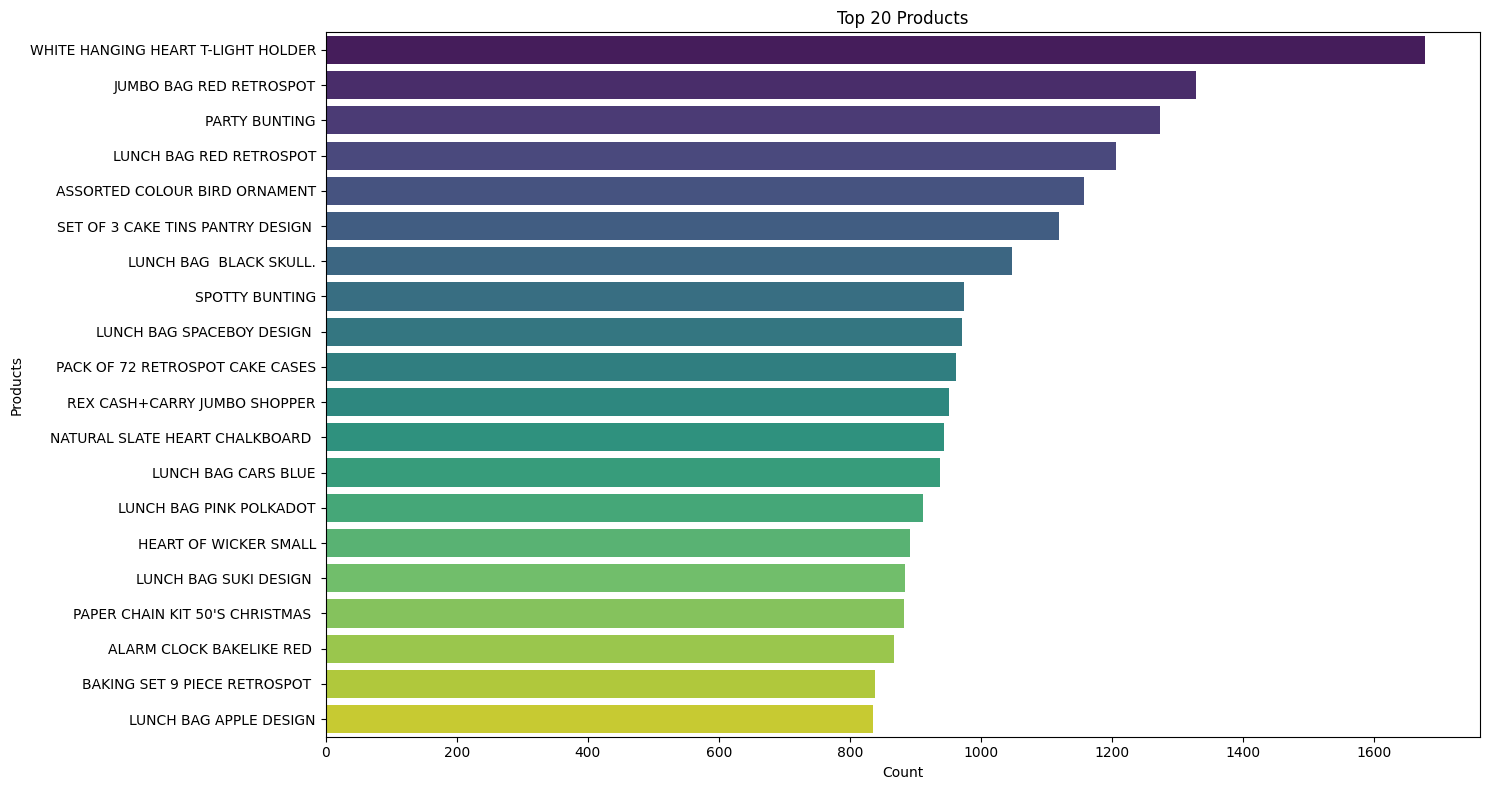

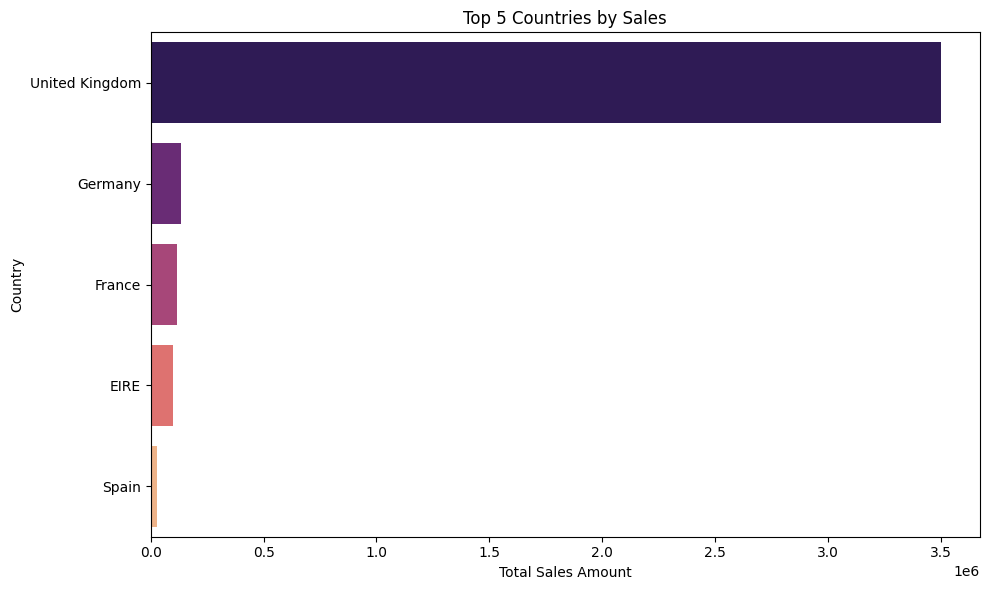

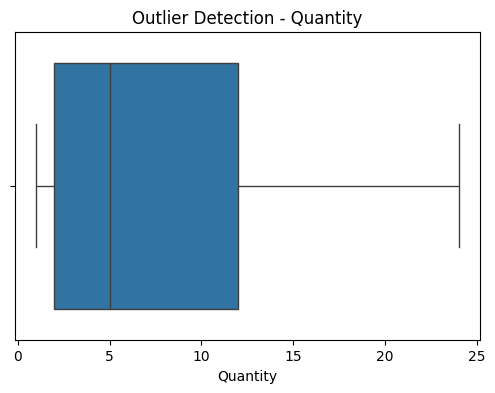

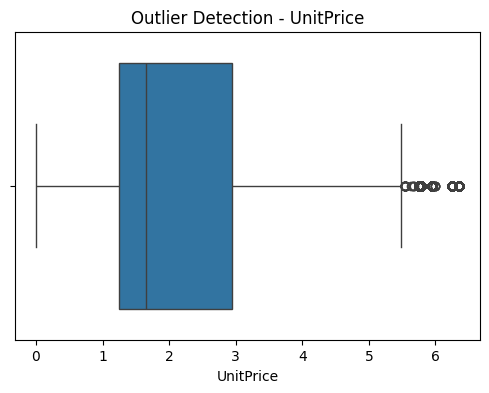

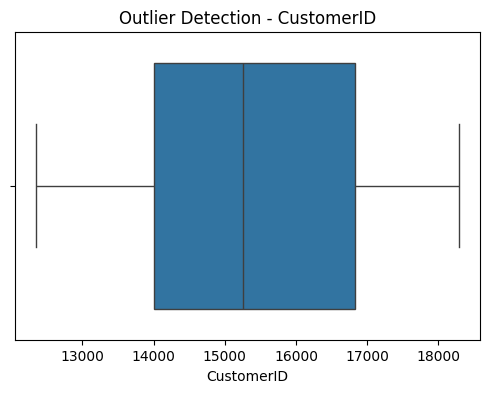

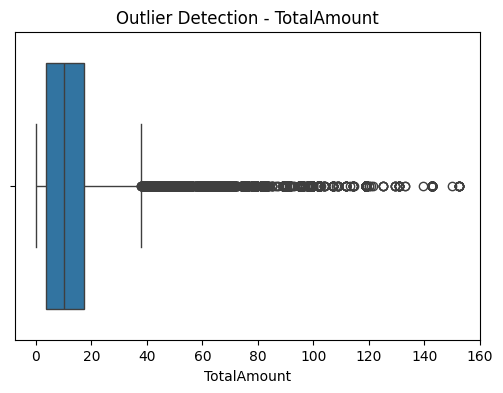

In [2]:
# Data Visualization
num_cols = df.select_dtypes(include = ["int64", "float64"])
cat_cols = df.select_dtypes(include = ["str"])

top_20_products = (df.groupby("Description")["StockCode"].count().sort_values(ascending=False).head(20))
top_5_countries = (df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(5))

# Plot Top 20 Products
plt.figure(figsize=(15, 8))
sns.barplot(x = top_20_products.values, y = top_20_products.index, hue = top_20_products.index, palette="viridis")
plt.xlabel("Count")
plt.ylabel("Products")
plt.title("Top 20 Products")
plt.tight_layout()
plt.show()

# Plot Top 5 Countries
plt.figure(figsize=(10, 6))
sns.barplot(x = top_5_countries.values, y = top_5_countries.index, hue = top_5_countries.index, palette="magma")
plt.xlabel("Total Sales Amount")
plt.ylabel("Country")
plt.title("Top 5 Countries by Sales")
plt.tight_layout()
plt.show()

# Outlier Detection
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.show()

,Recency,Frequency,Monetary
CustomerID,,,
12347,-0.906752,0.430602,1.126188
12348,1.565155,-0.142484,-0.427372
12349,-0.736621,-0.429027,-0.006790
12350,2.175626,-0.429027,-0.328989
12352,-0.566490,0.430602,0.074051


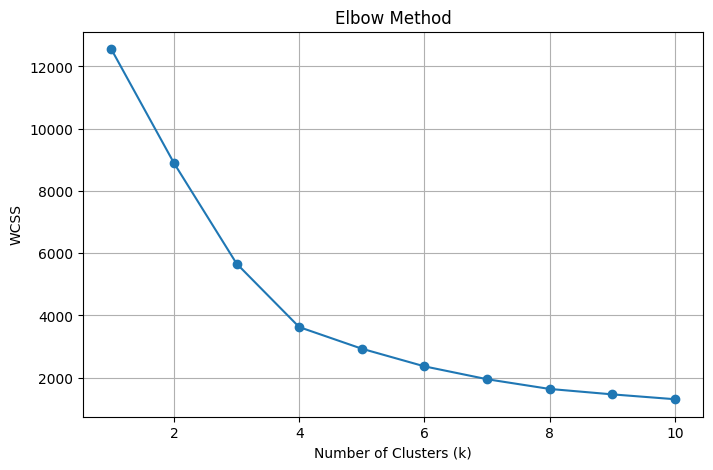

In [3]:
# Model Training 
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (df["InvoiceDate"].max() - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)
display(rfm_scaled.head())

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [4]:
# Model Evaluation 
score = silhouette_score(rfm_scaled, rfm["Cluster"])
print("\nSilhouette Score:", round(score, 4))


Silhouette Score: 0.5804


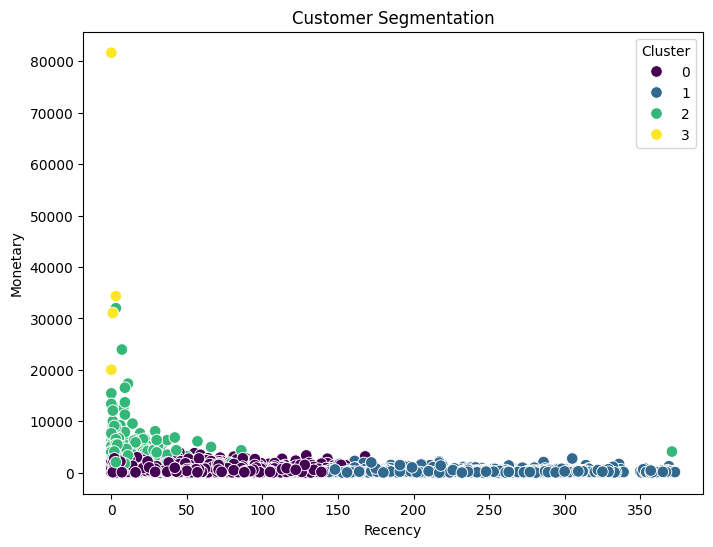

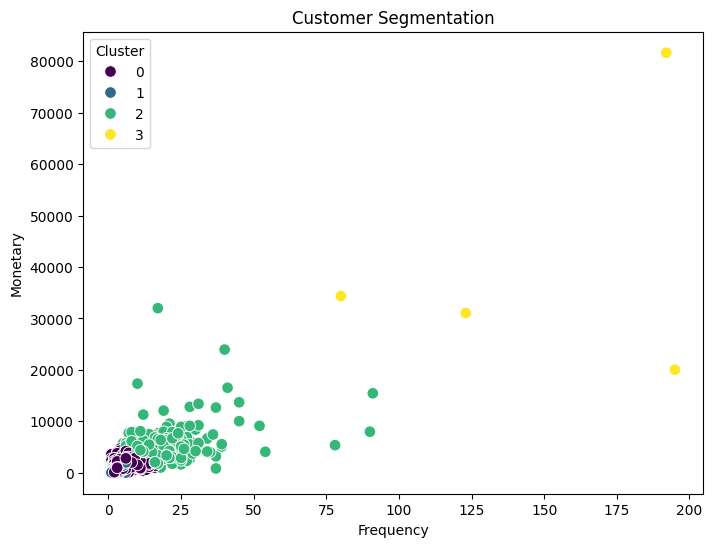

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="viridis", s=70)
plt.title("Customer Segmentation")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="viridis", s=70)
plt.title("Customer Segmentation")
plt.show()

In [6]:
cluster_summary = rfm.groupby("Cluster").mean()
customer_count = rfm["Cluster"].value_counts().sort_index()
revenue = rfm.groupby("Cluster")["Monetary"].sum()
customer_percent = (customer_count / customer_count.sum() * 100).round(2)
revenue_percent = (revenue / revenue.sum() * 100).round(2)

display(cluster_summary)
display(customer_percent)
display(revenue_percent)

,Recency,Frequency,Monetary
Cluster,,,
0,42.933681,3.401736,809.419810
1,245.999041,1.507191,292.183702
2,12.162791,18.441860,4987.637287
3,1.000000,147.500000,41767.820000


Cluster
0    68.82
1    24.92
2     6.16
3     0.10
Name: count, dtype: float64

Cluster
0    57.00
1     7.45
2    31.46
3     4.09
Name: Monetary, dtype: float64